# Segment-Specific ML Modelling: Tea Auction Price Forecasting

**Objective**: Predict next-week `price_mid_lkr` for each tea catalogue using the `final_clean_dataset_long.csv` dataset.

**Catalogues**: `high_grown` | `low_grown` | `off_grade` | `dust`

**Models benchmarked**: XGBoost · LightGBM · Random Forest · Gradient Boosting

**Strategy**: Separate model per catalogue · TimeSeriesSplit CV (5-fold) · 80/20 temporal train/test split

**Features**: Price lags (1–3 weeks) · Rolling stats · Weather features (current + 3 lags) · FX · Grade/Tier/Region (encoded) · Seasonality

## 1. Setup & Configuration

In [7]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [8]:
# ── Paths ────────────────────────────────────────────────────────────────────
DATA_PATH  = Path('../data/processed/final_clean_dataset_long.csv')
OUTPUT_DIR = Path('../results')

# ── Experiment settings ──────────────────────────────────────────────────────
CATALOGUES       = ['high_grown', 'low_grown', 'off_grade', 'dust']
N_CV_SPLITS      = 5
RANDOM_STATE     = 42
TEST_SPLIT_RATIO = 0.20   # last 20% of chronological data held out for test

# ── Visual palette ───────────────────────────────────────────────────────────
MODEL_COLORS = {
    'XGBoost'          : '#E74C3C',
    'LightGBM'         : '#27AE60',
    'RandomForest'     : '#2980B9',
    'GradientBoosting' : '#F39C12'
}

print('Configuration set.')

Configuration set.


## 2. Data Loading & EDA

In [9]:
df_raw = pd.read_csv(DATA_PATH)

print(f'Shape : {df_raw.shape}')
print(f'\nCatalogue distribution:')
print(df_raw['catalogue'].value_counts().to_string())
print(f'\nSale years  : {df_raw["sale_year"].min():.0f} – {df_raw["sale_year"].max():.0f}')
print(f'Sale numbers: {df_raw["sale_number"].min():.0f} – {df_raw["sale_number"].max():.0f}')
print(f'\nMissing price_mid_lkr: {df_raw["price_mid_lkr"].isna().sum()}')
print(f'\nPrice statistics by catalogue:')
display(df_raw.groupby('catalogue')['price_mid_lkr']
          .describe().round(1)
          .rename(columns={'count':'n','mean':'mean LKR','std':'std','min':'min','50%':'median','max':'max'}))

Shape : (12233, 26)

Catalogue distribution:
catalogue
low_grown     5384
off_grade     2520
dust          2205
high_grown    2124

Sale years  : 2023 – 2026
Sale numbers: 1 – 51

Missing price_mid_lkr: 436

Price statistics by catalogue:


,n,mean LKR,std,min,25%,median,75%,max
catalogue,,,,,,,,
dust,2171.0,974.1,190.4,620.0,825.0,950.0,1110.0,2030.0
high_grown,2124.0,1172.6,224.7,760.0,1020.0,1150.0,1290.0,3050.0
low_grown,5384.0,1612.0,792.3,725.0,1100.0,1410.0,1800.0,6750.0
off_grade,2118.0,824.1,146.6,520.0,701.2,790.0,940.0,1285.0


## 3. Feature Engineering

In [10]:
df = df_raw.copy()

df = df.dropna(subset=['price_mid_lkr']).copy()


df = df.sort_values(['sale_year', 'sale_number', 'catalogue', 'grade', 'tier'])
df = df.reset_index(drop=True)

df['time_idx'] = df.groupby(['sale_year', 'sale_number']).ngroup()

GROUP = ['catalogue', 'grade', 'tier']

for lag in [1, 2, 3]:
    df[f'price_lag{lag}'] = df.groupby(GROUP)['price_mid_lkr'].shift(lag)

df['price_roll_mean3'] = (
    df.groupby(GROUP)['price_mid_lkr']
      .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)
df['price_roll_std3'] = (
    df.groupby(GROUP)['price_mid_lkr']
      .transform(lambda x: x.shift(1).rolling(3, min_periods=2).std().fillna(0))
)

# ── Target: next auction's price for the same (catalogue, grade, tier) ────────
df['price_next_week'] = df.groupby(GROUP)['price_mid_lkr'].shift(-1)

# Drop rows where target is unavailable (last row of each product group)
df = df.dropna(subset=['price_next_week']).copy()
df = df.reset_index(drop=True)

print(f'Shape after feature engineering: {df.shape}')
print(f'Time periods (auctions): {df["time_idx"].nunique()}')
print(f'\nLag NaN counts (filled downstream):')
print(df[['price_lag1', 'price_lag2', 'price_lag3']].isna().sum().to_string())
print(f'\nTarget (price_next_week) stats:')
display(df.groupby('catalogue')['price_next_week'].describe().round(1))

Shape after feature engineering: (11739, 33)
Time periods (auctions): 105

Lag NaN counts (filled downstream):
price_lag1     58
price_lag2    116
price_lag3    174

Target (price_next_week) stats:


,count,mean,std,min,25%,50%,75%,max
catalogue,,,,,,,,
dust,2170.0,974.0,190.4,620.0,825.0,950.0,1110.0,2030.0
high_grown,2120.0,1172.9,224.7,760.0,1020.0,1150.0,1290.0,3050.0
low_grown,5332.0,1613.9,793.6,725.0,1105.0,1415.0,1800.0,6750.0
off_grade,2117.0,824.0,146.5,520.0,700.0,790.0,940.0,1285.0


## 4. Preprocessing & Model Definitions

In [11]:
# ── Feature lists ─────────────────────────────────────────────────────────────
CAT_FEATURES = ['grade', 'tier', 'category', 'region', 'segment', 'elevation', 'text_crop_change']

NUM_FEATURES = [
    'sale_number', 'sale_year', 'time_idx',
    'temperature_2m_mean_mean',
    'precipitation_sum_total_lag1', 'sunshine_duration_total_lag1', 'temperature_2m_mean_mean_lag1',
    'precipitation_sum_total_lag2', 'sunshine_duration_total_lag2', 'temperature_2m_mean_mean_lag2',
    'precipitation_sum_total_lag3', 'sunshine_duration_total_lag3', 'temperature_2m_mean_mean_lag3',
    'avg_weather_severity', 'fx_usd',
    'price_lag1', 'price_lag2', 'price_lag3',
    'price_roll_mean3', 'price_roll_std3'
]

TARGET = 'price_next_week'


def prepare_features(data, cat_features=CAT_FEATURES, num_features=NUM_FEATURES):
    """Encode categoricals, fill NaN, drop constant columns. Returns (X, y, feature_names)."""
    d = data.copy()
    for col in cat_features:
        if col in d.columns:
            d[col] = LabelEncoder().fit_transform(d[col].fillna('unknown').astype(str))

    avail = [c for c in num_features + cat_features if c in d.columns]
    X_df = d[avail].copy()
    X_df = X_df.loc[:, X_df.nunique() > 1]   # drop constants

    return X_df.values, d[TARGET].values, list(X_df.columns)


print('Preprocessing utilities defined.')

Preprocessing utilities defined.


In [12]:
# ── Model zoo (consistent hyperparameter grid for fair comparison) ────────────
MODELS = {
    'XGBoost': xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, verbosity=0
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, verbose=-1
    ),
    'RandomForest': RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_leaf=5,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, random_state=RANDOM_STATE
    )
}

print(f'Models registered: {list(MODELS.keys())}')

Models registered: ['XGBoost', 'LightGBM', 'RandomForest', 'GradientBoosting']


## 5. Evaluation Utilities

In [13]:
def train_evaluate_catalogue(catalogue_name, df_cat, models=MODELS, n_splits=N_CV_SPLITS):
    
    print(f'\n{"="*68}')
    print(f'  CATALOGUE : {catalogue_name.upper().replace("_", " ")}  |  n = {len(df_cat)}')
    print(f'{"="*68}')

    df_cat = df_cat.sort_values('time_idx').reset_index(drop=True)
    X, y, feat_names = prepare_features(df_cat)

    split_idx = int(len(X) * (1 - TEST_SPLIT_RATIO))
    X_tr, X_te = X[:split_idx], X[split_idx:]
    y_tr, y_te = y[:split_idx], y[split_idx:]

    print(f'  Features: {len(feat_names)}  |  Train: {len(X_tr)}  |  Test: {len(X_te)}')

    tscv    = TimeSeriesSplit(n_splits=n_splits)
    results = []
    artifacts = {}

    for name, model in models.items():
        # ── TimeSeriesSplit CV ──────────────────────────────────────────────
        cv_rmse, cv_mae = [], []
        for tr_idx, val_idx in tscv.split(X_tr):
            pipe = Pipeline([("impute", SimpleImputer(strategy="median")),
                             ("model",  clone(model))])
            pipe.fit(X_tr[tr_idx], y_tr[tr_idx])
            p = pipe.predict(X_tr[val_idx])
            cv_rmse.append(np.sqrt(mean_squared_error(y_tr[val_idx], p)))
            cv_mae.append(mean_absolute_error(y_tr[val_idx], p))

        # ── Final model on full training data ──────────────────────────────
        m_final = Pipeline([("impute", SimpleImputer(strategy="median")),
                            ("model",  clone(model))])
        m_final.fit(X_tr, y_tr)
        y_pred = m_final.predict(X_te)

        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        r2   = r2_score(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / np.maximum(y_te, 1))) * 100

        results.append({
            'catalogue'    : catalogue_name,
            'model'        : name,
            'cv_rmse_mean' : np.mean(cv_rmse),
            'cv_rmse_std'  : np.std(cv_rmse),
            'cv_mae_mean'  : np.mean(cv_mae),
            'test_rmse'    : rmse,
            'test_mae'     : mae,
            'test_r2'      : r2,
            'test_mape'    : mape,
        })
        artifacts[name] = {
            'model'      : m_final['model'],
            'y_test'     : y_te,
            'y_pred'     : y_pred,
            'feat_names' : feat_names
        }

        print(f'  {name:22s}  CV RMSE {np.mean(cv_rmse):7.2f} ± {np.std(cv_rmse):.2f}'
              f'  |  Test RMSE {rmse:7.2f}  R² {r2:.4f}  MAPE {mape:.1f}%')

    df_res = pd.DataFrame(results)
    best   = df_res.loc[df_res['test_rmse'].idxmin(), 'model']
    best_row = df_res[df_res['model'] == best].iloc[0]
    print(f'\n  >> Best: {best}  '
          f'(RMSE={best_row["test_rmse"]:.2f}  R²={best_row["test_r2"]:.4f}  MAPE={best_row["test_mape"]:.1f}%)')

    return df_res, best, artifacts


print('Evaluation function defined.')

Evaluation function defined.


## 6. Segment-Specific Modelling

In [14]:
all_results   = []
best_models   = {}   # catalogue -> best model name
all_artifacts = {}   # catalogue -> {model_name -> artifact dict}

for cat in CATALOGUES:
    df_cat = df[df['catalogue'] == cat].copy()
    if len(df_cat) < 100:
        print(f'Skipping {cat}: only {len(df_cat)} rows.')
        continue

    res_df, best, artifacts = train_evaluate_catalogue(cat, df_cat)
    all_results.append(res_df)
    best_models[cat]   = best
    all_artifacts[cat] = artifacts

results_all = pd.concat(all_results, ignore_index=True)
print('\n\nAll catalogues modelled successfully.')


  CATALOGUE : HIGH GROWN  |  n = 2120
  Features: 25  |  Train: 1696  |  Test: 424
  XGBoost                 CV RMSE  159.92 ± 48.13  |  Test RMSE  187.82  R² 0.0487  MAPE 10.3%
  LightGBM                CV RMSE  156.79 ± 53.31  |  Test RMSE  154.88  R² 0.3531  MAPE 9.3%
  RandomForest            CV RMSE  151.55 ± 57.74  |  Test RMSE  175.51  R² 0.1692  MAPE 10.5%
  GradientBoosting        CV RMSE  162.88 ± 51.34  |  Test RMSE  193.37  R² -0.0084  MAPE 10.7%

  >> Best: LightGBM  (RMSE=154.88  R²=0.3531  MAPE=9.3%)

  CATALOGUE : LOW GROWN  |  n = 5332
  Features: 25  |  Train: 4265  |  Test: 1067
  XGBoost                 CV RMSE  129.05 ± 22.03  |  Test RMSE  113.25  R² 0.9760  MAPE 3.5%
  LightGBM                CV RMSE  142.56 ± 39.63  |  Test RMSE  103.02  R² 0.9801  MAPE 3.3%
  RandomForest            CV RMSE  137.43 ± 39.83  |  Test RMSE  112.37  R² 0.9763  MAPE 3.2%
  GradientBoosting        CV RMSE  137.63 ± 27.23  |  Test RMSE  123.79  R² 0.9713  MAPE 3.4%

  >> Best: LightG

## 7. Benchmark Results

In [15]:
print('=' * 90)
print('  BENCHMARK RESULTS — ALL CATALOGUES')
print('=' * 90)

# ── Full results table ────────────────────────────────────────────────────────
summary = results_all[[
    'catalogue', 'model', 'cv_rmse_mean', 'cv_rmse_std',
    'test_rmse', 'test_mae', 'test_r2', 'test_mape'
]].copy().sort_values(['catalogue', 'test_rmse'])
summary.columns = [
    'Catalogue', 'Model', 'CV RMSE', 'CV RMSE Std',
    'Test RMSE', 'Test MAE', 'Test R²', 'MAPE (%)'
]
display(summary.style
        .format({'CV RMSE': '{:.2f}', 'CV RMSE Std': '{:.2f}', 'Test RMSE': '{:.2f}',
                 'Test MAE': '{:.2f}', 'Test R²': '{:.4f}', 'MAPE (%)': '{:.1f}'})
        .set_caption('Full Benchmark Table (sorted by Test RMSE per catalogue)')
)

# ── RMSE pivot ────────────────────────────────────────────────────────────────
print('\nTest RMSE pivot (rows = catalogue, columns = model):')
pivot_rmse = results_all.pivot_table(
    index='catalogue', columns='model', values='test_rmse', aggfunc='first'
).round(2)
pivot_rmse.columns.name = None
display(pivot_rmse)

# ── Best-model summary ────────────────────────────────────────────────────────
print('\n' + '-' * 70)
print('  BEST MODEL PER CATALOGUE')
print('-' * 70)
for cat in CATALOGUES:
    if cat not in best_models:
        continue
    best = best_models[cat]
    row  = results_all[(results_all['catalogue'] == cat) & (results_all['model'] == best)].iloc[0]
    n    = len(df[df['catalogue'] == cat])
    print(f'  {cat.upper().replace("_", " "):15s}  →  {best:22s}'
          f'  RMSE={row["test_rmse"]:7.2f}  R²={row["test_r2"]:.4f}  MAPE={row["test_mape"]:.1f}%  (n={n})')

  BENCHMARK RESULTS — ALL CATALOGUES


,Catalogue,Model,CV RMSE,CV RMSE Std,Test RMSE,Test MAE,Test R²,MAPE (%)
13,dust,LightGBM,110.79,45.80,101.68,71.77,0.7340,7.1
15,dust,GradientBoosting,113.64,48.94,103.77,72.77,0.7230,7.2
12,dust,XGBoost,115.31,51.92,109.27,75.94,0.6929,7.4
14,dust,RandomForest,116.64,54.30,119.87,83.00,0.6303,8.2
1,high_grown,LightGBM,156.79,53.31,154.88,110.48,0.3531,9.3
2,high_grown,RandomForest,151.55,57.74,175.51,124.41,0.1692,10.5
0,high_grown,XGBoost,159.92,48.13,187.82,123.50,0.0487,10.3
3,high_grown,GradientBoosting,162.88,51.34,193.37,128.90,-0.0084,10.7
5,low_grown,LightGBM,142.56,39.63,103.02,58.25,0.9801,3.3
6,low_grown,RandomForest,137.43,39.83,112.37,57.11,0.9763,3.2



Test RMSE pivot (rows = catalogue, columns = model):


,GradientBoosting,LightGBM,RandomForest,XGBoost
catalogue,,,,
dust,103.77,101.68,119.87,109.27
high_grown,193.37,154.88,175.51,187.82
low_grown,123.79,103.02,112.37,113.25
off_grade,116.92,118.02,116.50,122.17



----------------------------------------------------------------------
  BEST MODEL PER CATALOGUE
----------------------------------------------------------------------
  HIGH GROWN       →  LightGBM                RMSE= 154.88  R²=0.3531  MAPE=9.3%  (n=2120)
  LOW GROWN        →  LightGBM                RMSE= 103.02  R²=0.9801  MAPE=3.3%  (n=5332)
  OFF GRADE        →  RandomForest            RMSE= 116.50  R²=0.4921  MAPE=12.4%  (n=2117)
  DUST             →  LightGBM                RMSE= 101.68  R²=0.7340  MAPE=7.1%  (n=2170)


## 8. Visualisations

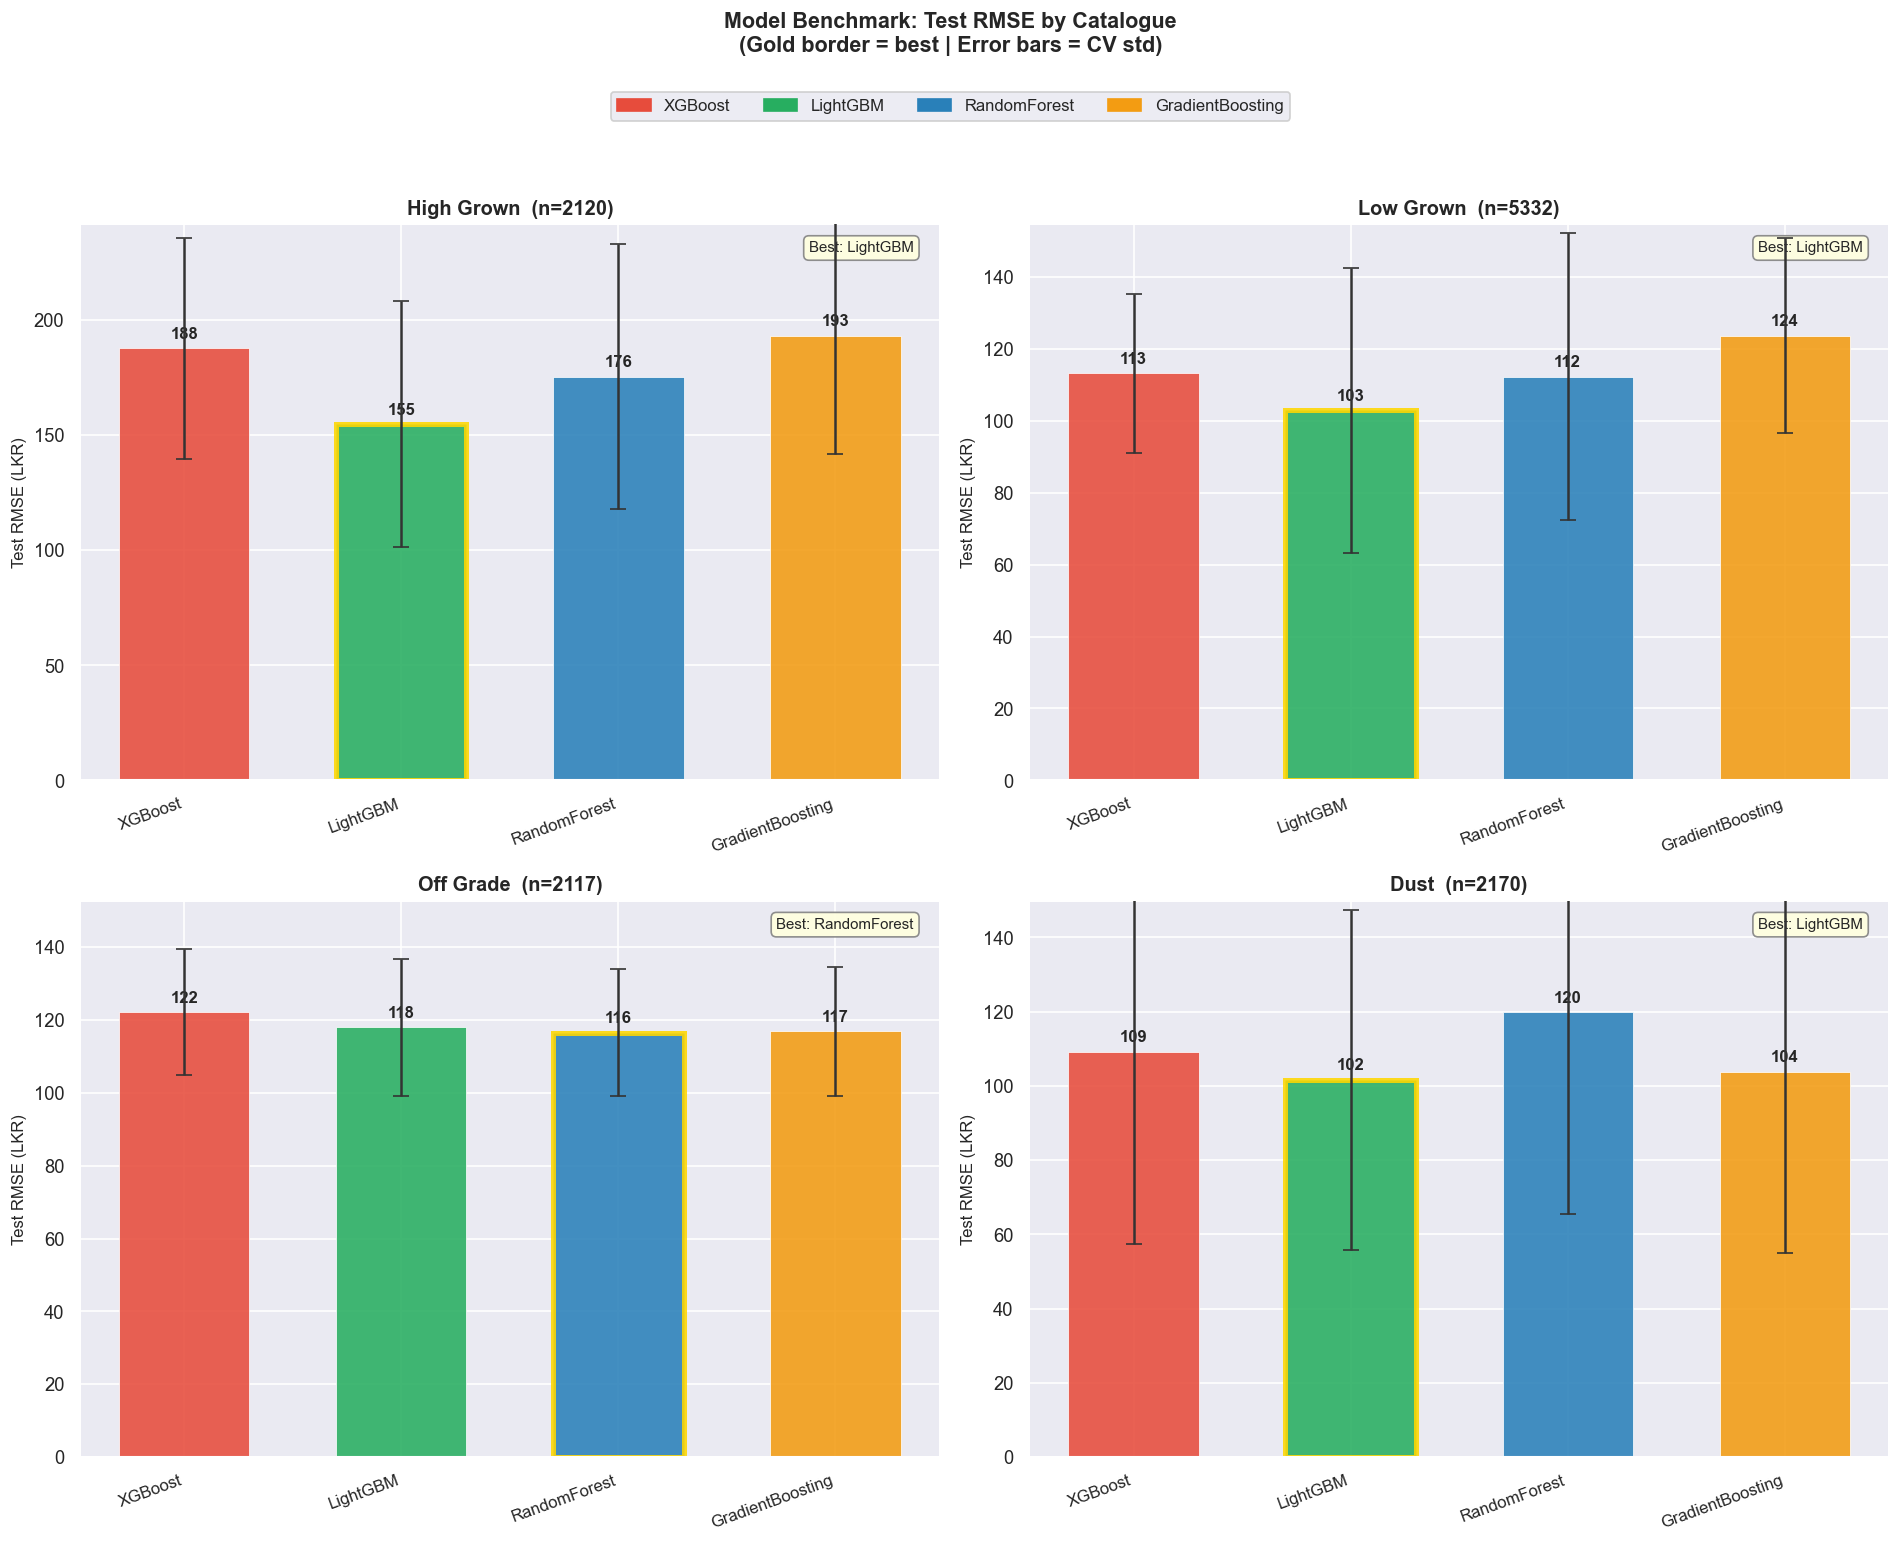

Saved: benchmark_rmse_by_catalogue.png


In [17]:
# ── 8a. RMSE bar chart per catalogue ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, cat in enumerate(CATALOGUES):
    ax  = axes[idx]
    cat_res = results_all[results_all['catalogue'] == cat].copy()
    model_names = list(cat_res['model'])

    colors = [MODEL_COLORS[m] for m in model_names]
    bars   = ax.bar(range(len(cat_res)), cat_res['test_rmse'],
                    color=colors, alpha=0.88, edgecolor='white', linewidth=0.5, width=0.6)

    # CV std as error bars
    ax.errorbar(range(len(cat_res)), cat_res['test_rmse'],
                yerr=cat_res['cv_rmse_std'],
                fmt='none', color='#333', capsize=5, linewidth=1.5, zorder=5)

    # Gold border on best
    best_local_idx = int(cat_res['test_rmse'].values.argmin())
    bars[best_local_idx].set_edgecolor('#FFD700')
    bars[best_local_idx].set_linewidth(3)

    # Value labels
    ymax = cat_res['test_rmse'].max()
    for i, (bar, row) in enumerate(zip(bars, cat_res.itertuples())):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + ymax * 0.015,
                f'{row.test_rmse:.0f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

    ax.set_xticks(range(len(cat_res)))
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=10)
    ax.set_ylabel('Test RMSE (LKR)', fontsize=10)
    ax.set_ylim(0, ymax * 1.25)
    n_cat = len(df[df['catalogue'] == cat])
    ax.set_title(f"{cat.replace('_', ' ').title()}  (n={n_cat})",
                 fontsize=12, fontweight='bold')
    best_name = cat_res.loc[cat_res['test_rmse'].idxmin(), 'model']
    ax.text(0.97, 0.97, f'Best: {best_name}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='lightyellow',
                      edgecolor='#888', alpha=0.95))

# shared legend
patches = [mpatches.Patch(color=c, label=m) for m, c in MODEL_COLORS.items()]
fig.legend(handles=patches, loc='upper center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, 1.02), framealpha=0.9)

fig.suptitle('Model Benchmark: Test RMSE by Catalogue\n'
             '(Gold border = best | Error bars = CV std)',
             fontsize=13, fontweight='bold', y=1.07)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'benchmark_rmse_by_catalogue.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: benchmark_rmse_by_catalogue.png')

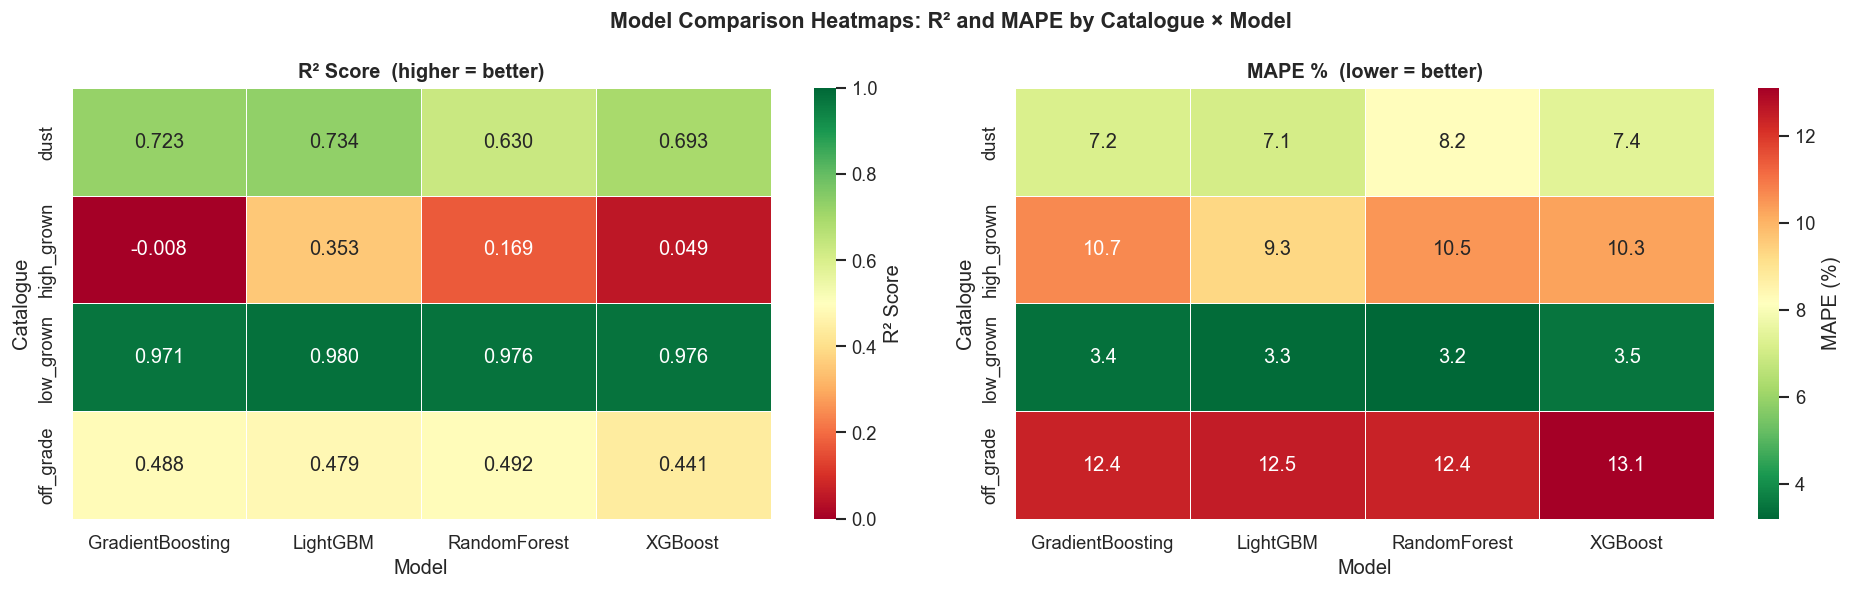

Saved: benchmark_r2_mape_heatmap.png


In [18]:
# ── 8b. R² heatmap  +  MAPE heatmap ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

pivot_r2 = results_all.pivot_table(
    index='catalogue', columns='model', values='test_r2', aggfunc='first'
)
pivot_r2.columns.name = None
sns.heatmap(pivot_r2.round(3), annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax1, linewidths=0.5,
            cbar_kws={'label': 'R² Score'})
ax1.set_title('R² Score  (higher = better)', fontweight='bold', fontsize=12)
ax1.set_xlabel('Model'); ax1.set_ylabel('Catalogue')

pivot_mape = results_all.pivot_table(
    index='catalogue', columns='model', values='test_mape', aggfunc='first'
)
pivot_mape.columns.name = None
sns.heatmap(pivot_mape.round(1), annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=ax2, linewidths=0.5,
            cbar_kws={'label': 'MAPE (%)'})
ax2.set_title('MAPE %  (lower = better)', fontweight='bold', fontsize=12)
ax2.set_xlabel('Model'); ax2.set_ylabel('Catalogue')

fig.suptitle('Model Comparison Heatmaps: R² and MAPE by Catalogue × Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'benchmark_r2_mape_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: benchmark_r2_mape_heatmap.png')

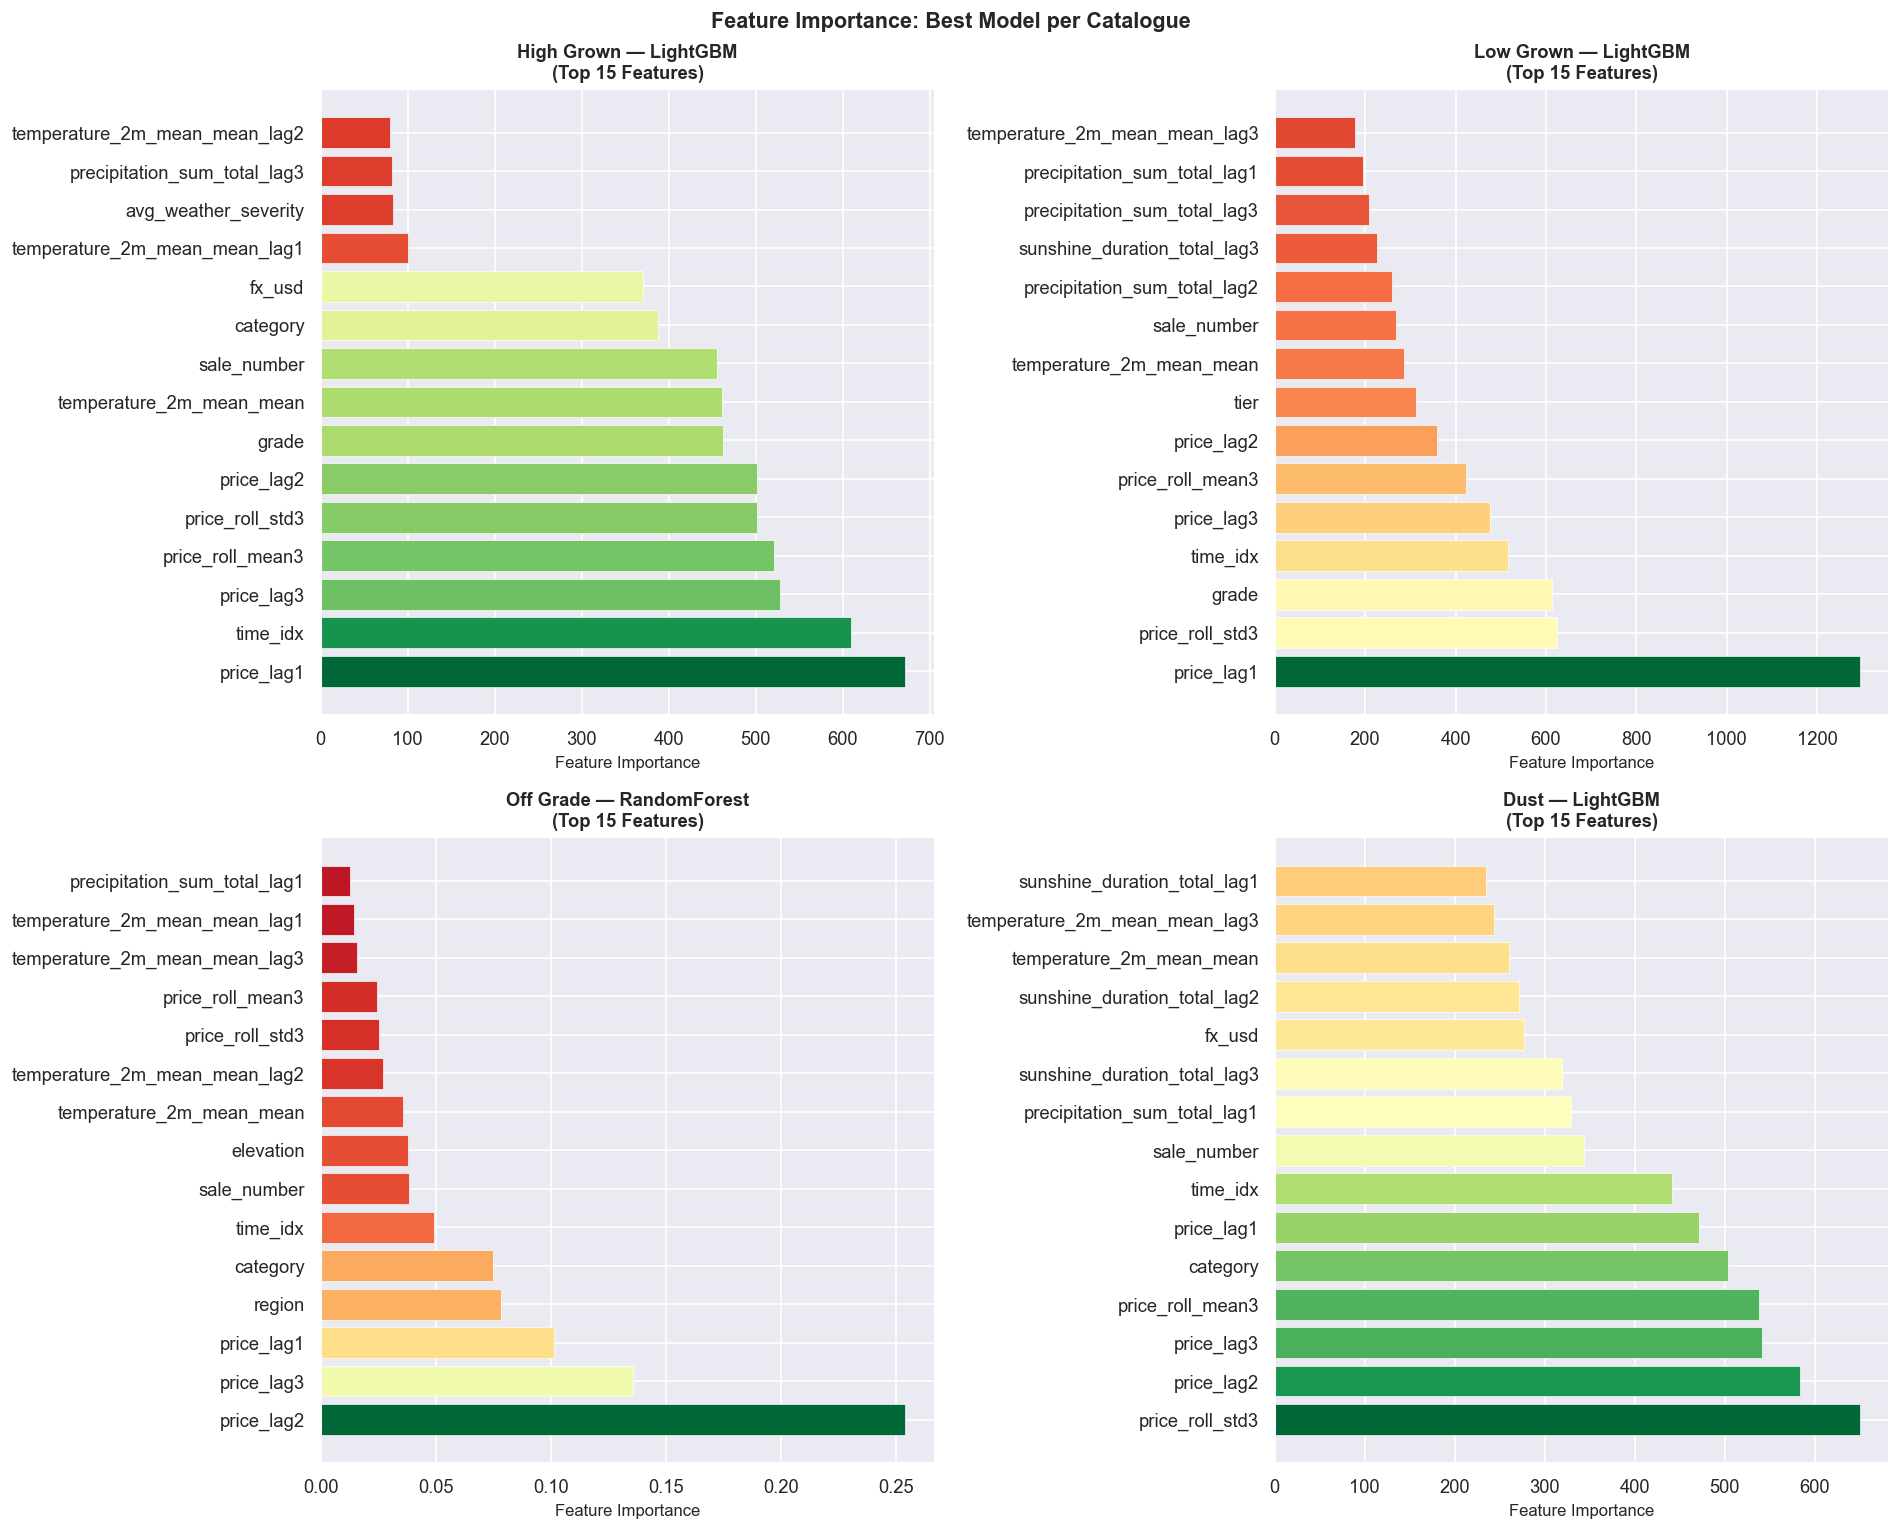

Saved: best_model_feature_importance.png


In [20]:
# ── 8c. Feature importance — best model per catalogue ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flatten()

for idx, cat in enumerate(CATALOGUES):
    if cat not in best_models:
        axes[idx].set_visible(False)
        continue

    ax        = axes[idx]
    best      = best_models[cat]
    art       = all_artifacts[cat][best]
    importances = art['model'].feature_importances_
    feat_names  = art['feat_names']

    top_n   = min(15, len(feat_names))
    indices = np.argsort(importances)[-top_n:]
    vals    = importances[indices]

    norm_vals = vals / vals.max()
    colors    = plt.cm.RdYlGn(norm_vals)

    ax.barh([feat_names[i] for i in indices], vals, color=colors, edgecolor='white', linewidth=0.4)
    ax.set_xlabel('Feature Importance', fontsize=10)
    ax.set_title(f"{cat.replace('_', ' ').title()} — {best}\n(Top {top_n} Features)",
                 fontweight='bold', fontsize=11)
    ax.invert_yaxis()

fig.suptitle('Feature Importance: Best Model per Catalogue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'best_model_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: best_model_feature_importance.png')

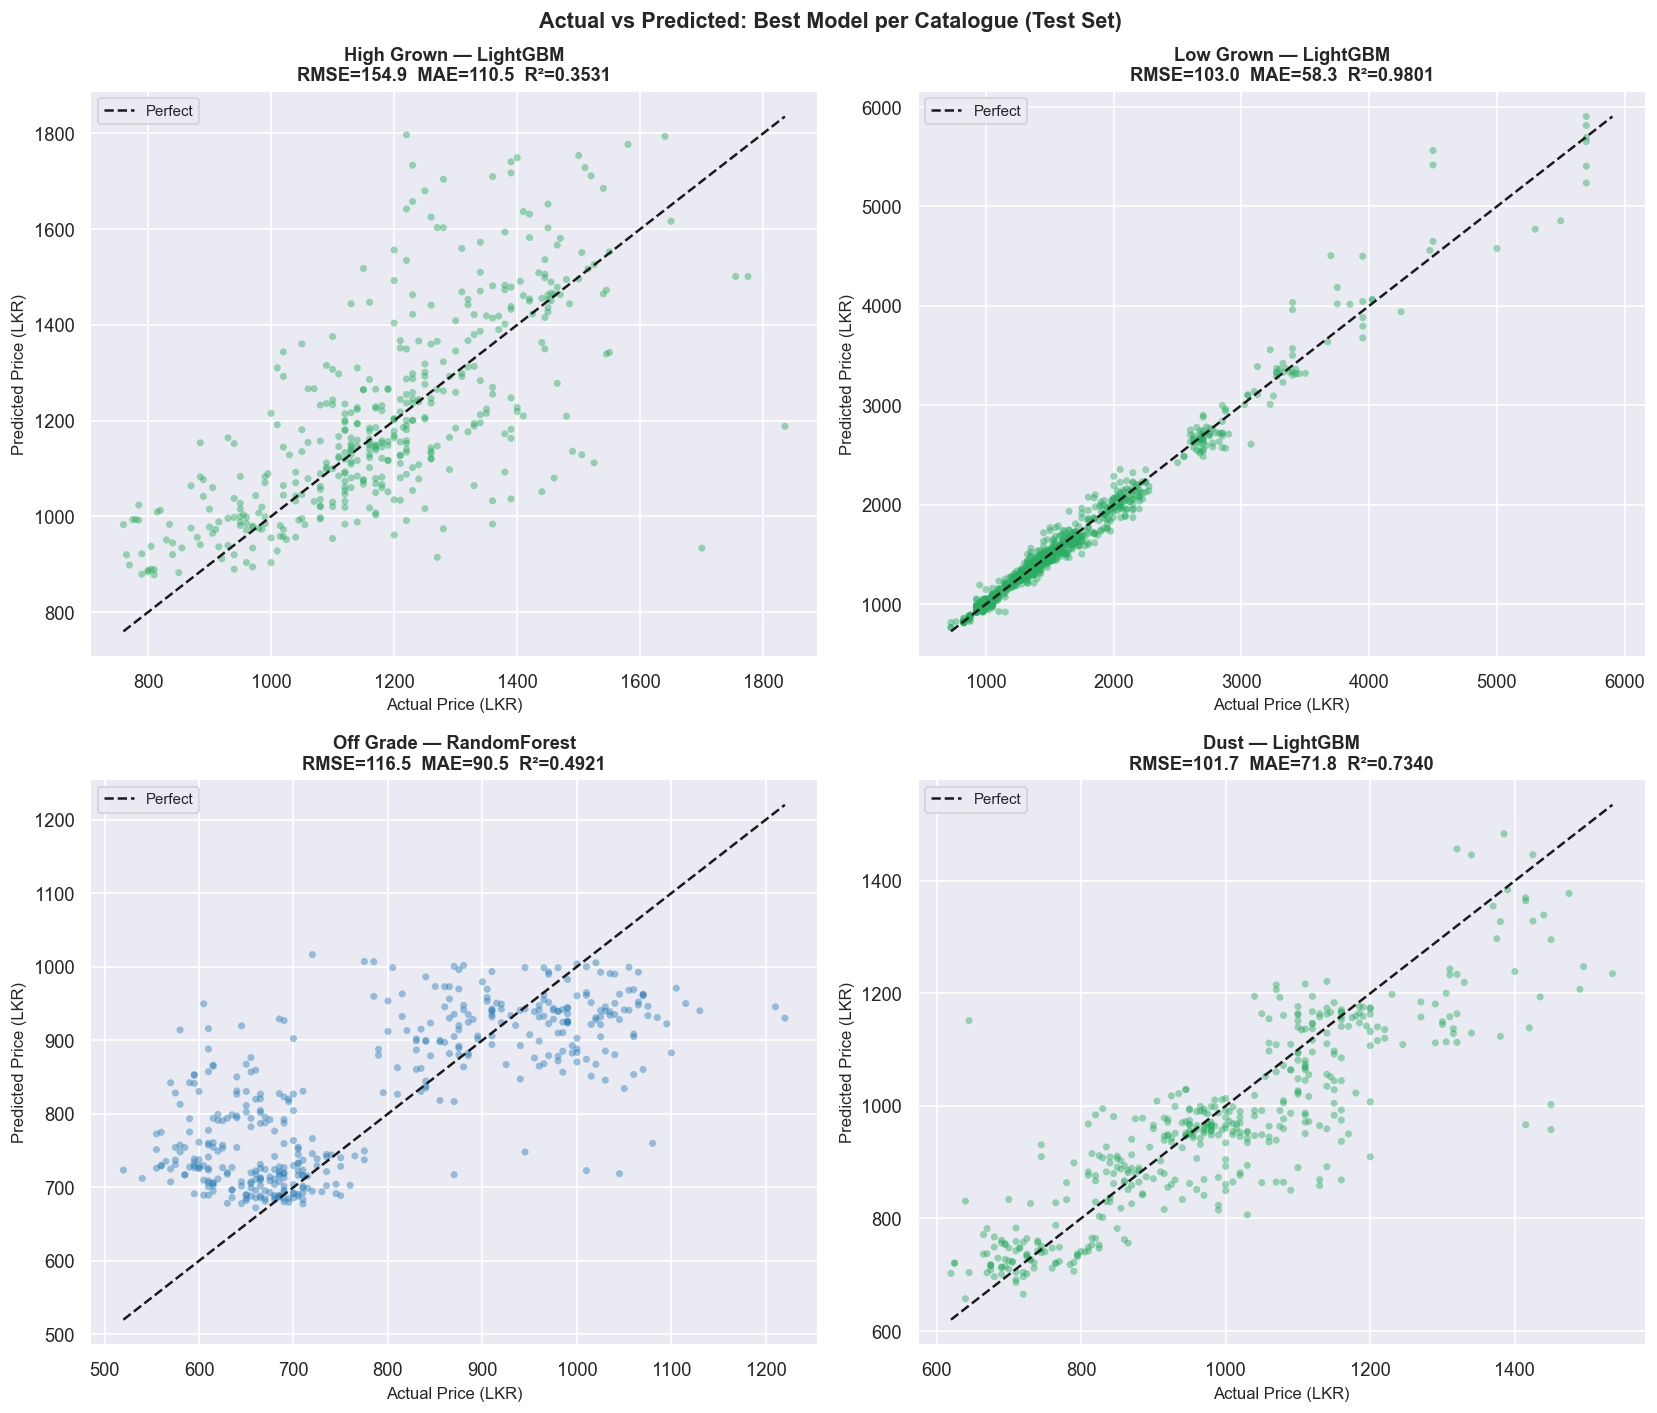

Saved: best_model_actual_vs_predicted.png


In [21]:
# ── 8d. Actual vs Predicted scatter — best model per catalogue ───────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, cat in enumerate(CATALOGUES):
    if cat not in best_models:
        axes[idx].set_visible(False)
        continue

    ax   = axes[idx]
    best = best_models[cat]
    art  = all_artifacts[cat][best]
    y_te = art['y_test']
    y_pr = art['y_pred']

    ax.scatter(y_te, y_pr, alpha=0.45, s=18, color=MODEL_COLORS[best], edgecolors='none')

    lo = min(y_te.min(), y_pr.min())
    hi = max(y_te.max(), y_pr.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='Perfect')

    row = results_all[
        (results_all['catalogue'] == cat) & (results_all['model'] == best)
    ].iloc[0]
    ax.set_xlabel('Actual Price (LKR)', fontsize=10)
    ax.set_ylabel('Predicted Price (LKR)', fontsize=10)
    ax.set_title(
        f"{cat.replace('_', ' ').title()} — {best}\n"
        f"RMSE={row['test_rmse']:.1f}  MAE={row['test_mae']:.1f}  R²={row['test_r2']:.4f}",
        fontweight='bold', fontsize=11
    )
    ax.legend(fontsize=9)

fig.suptitle('Actual vs Predicted: Best Model per Catalogue (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'best_model_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: best_model_actual_vs_predicted.png')

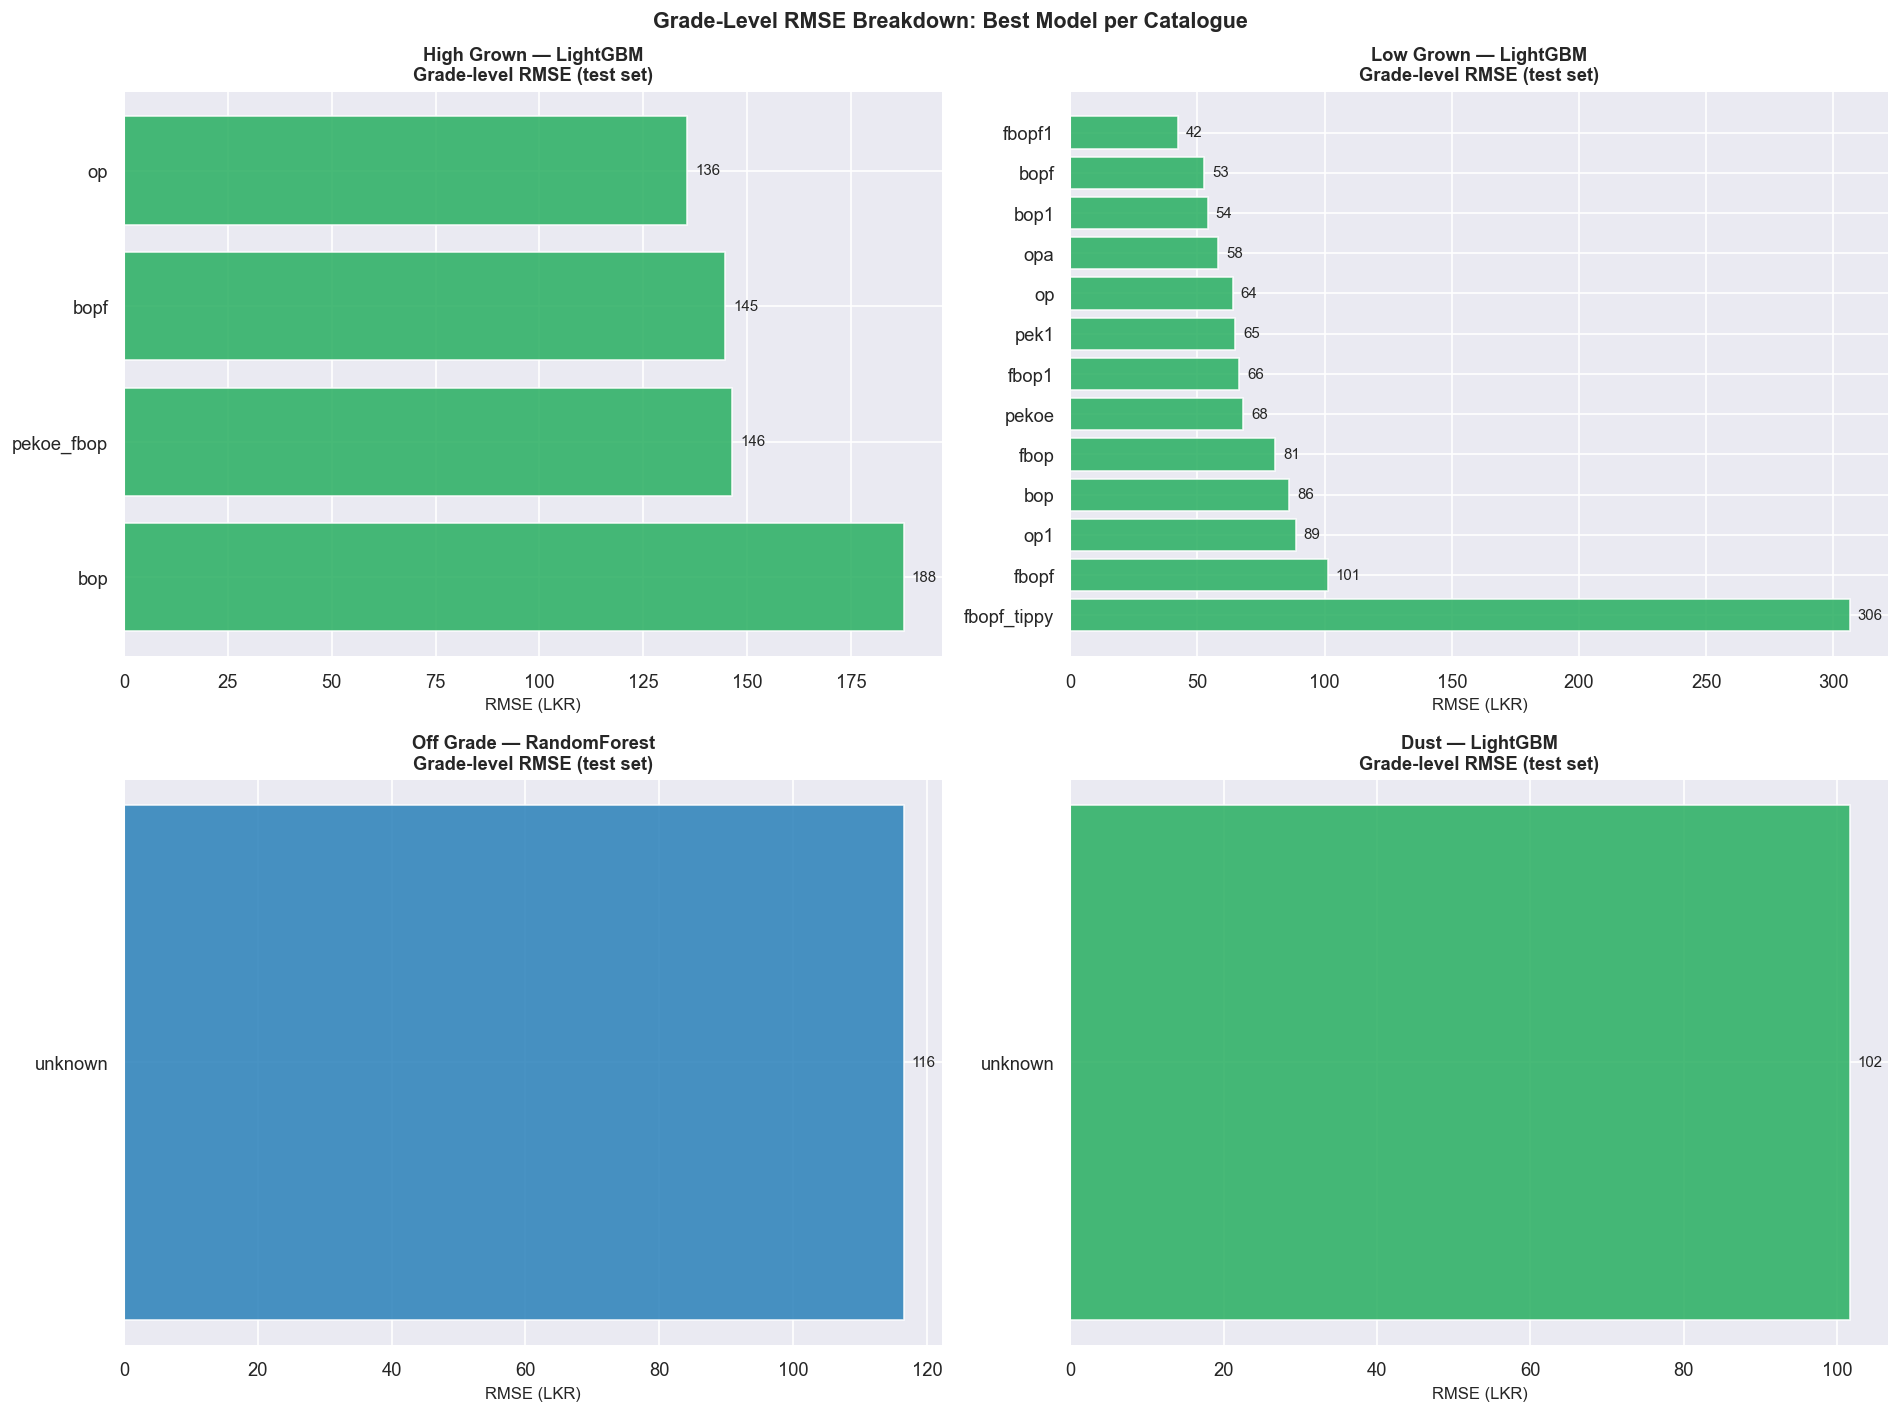

Saved: grade_level_rmse_breakdown.png


In [22]:
# ── 8e. Grade-level RMSE breakdown within each catalogue (best model) ─────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, cat in enumerate(CATALOGUES):
    if cat not in best_models:
        axes[idx].set_visible(False)
        continue

    ax   = axes[idx]
    best = best_models[cat]
    art  = all_artifacts[cat][best]

    df_test = (
        df[df['catalogue'] == cat]
        .sort_values('time_idx')
        .reset_index(drop=True)
    )
    split_idx = int(len(df_test) * (1 - TEST_SPLIT_RATIO))
    df_test   = df_test.iloc[split_idx:].copy()
    df_test   = df_test.iloc[:len(art['y_test'])].copy()   # align lengths
    df_test['y_pred'] = art['y_pred']
    df_test['error']  = np.abs(df_test[TARGET] - df_test['y_pred'])

    grade_rmse = (
        df_test.groupby('grade')
        .apply(lambda g: np.sqrt(mean_squared_error(g[TARGET], g['y_pred'])))
        .sort_values(ascending=False)
        .reset_index()
    )
    grade_rmse.columns = ['grade', 'rmse']

    bars = ax.barh(grade_rmse['grade'], grade_rmse['rmse'],
                   color=MODEL_COLORS[best], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, grade_rmse['rmse']):
        ax.text(val + grade_rmse['rmse'].max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.0f}', va='center', fontsize=9)

    ax.set_xlabel('RMSE (LKR)', fontsize=10)
    ax.set_title(f"{cat.replace('_', ' ').title()} — {best}\nGrade-level RMSE (test set)",
                 fontweight='bold', fontsize=11)

fig.suptitle('Grade-Level RMSE Breakdown: Best Model per Catalogue',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'grade_level_rmse_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: grade_level_rmse_breakdown.png')

## 9. Final Recommendations

In [23]:
print('\n' + '=' * 75)
print('  FINAL MODEL RECOMMENDATIONS')
print('=' * 75)
print(f'{"":<18} {"Best Model":<22} {"RMSE":>8} {"MAE":>8} {"R²":>8} {"MAPE%":>7} {"n":>6}')
print('-' * 75)

for cat in CATALOGUES:
    if cat not in best_models:
        continue
    best = best_models[cat]
    row  = results_all[
        (results_all['catalogue'] == cat) & (results_all['model'] == best)
    ].iloc[0]
    n_cat = len(df[df['catalogue'] == cat])
    print(f"{cat.upper().replace('_', ' '):<18} {best:<22}"
          f" {row['test_rmse']:>8.2f} {row['test_mae']:>8.2f}"
          f" {row['test_r2']:>8.4f} {row['test_mape']:>7.1f} {n_cat:>6}")

print('=' * 75)
print('\nNotes:')
print('  • RMSE / MAE in Sri Lankan Rupees (LKR)')
print('  • Target: price_next_week (next auction mid-price for same catalogue/grade/tier)')
print('  • Train/Test split: 80/20 chronological  |  CV: 5-fold TimeSeriesSplit')
print('  • All models use consistent hyperparameters (300 estimators, lr=0.05 where applicable)')


  FINAL MODEL RECOMMENDATIONS
                   Best Model                 RMSE      MAE       R²   MAPE%      n
---------------------------------------------------------------------------
HIGH GROWN         LightGBM                 154.88   110.48   0.3531     9.3   2120
LOW GROWN          LightGBM                 103.02    58.25   0.9801     3.3   5332
OFF GRADE          RandomForest             116.50    90.53   0.4921    12.4   2117
DUST               LightGBM                 101.68    71.77   0.7340     7.1   2170

Notes:
  • RMSE / MAE in Sri Lankan Rupees (LKR)
  • Target: price_next_week (next auction mid-price for same catalogue/grade/tier)
  • Train/Test split: 80/20 chronological  |  CV: 5-fold TimeSeriesSplit
  • All models use consistent hyperparameters (300 estimators, lr=0.05 where applicable)
